Task 3 -- CycleGAN Image Style Transfer (Monet <-> Photo).
Author: Charvee

Architecture (own design, deliberately different from teammate's):
  - Generator: U-Net-style encoder-decoder with skip connections (4 downsampling /
    4 upsampling stages, BatchNorm2d) -- NOT the ResNet-with-residual-blocks design used by
    the teammate.
  - Discriminator: PatchGAN, BatchNorm2d (teammate used InstanceNorm2d).
  - Adversarial loss: vanilla GAN (BCEWithLogits), not LSGAN.
  - lambda_cycle=8, NO identity loss (lambda_identity=0) -- a deliberate simplification
    versus the teammate's cycle+identity loss combination.
  - Own independent data subsample: 400 Monet paintings + 400 photos (seed 7) from the
    shared monet_jpg/photo_jpg pools, at 128x128 resolution.

In [1]:
import glob
import itertools
import json
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Config

In [2]:
SEED = 7
IMG_SIZE = 128
N_MONET = 400
N_PHOTO = 400
N_TEST = 40
BATCH_SIZE = 4
EPOCHS = 40
LR = 2.5e-4
LAMBDA_CYCLE = 8.0
DECAY_START_EPOCH = 20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.path.abspath(".")
MEMBER_DIR = os.path.dirname(HERE)
DATA_DIR = os.path.join(MEMBER_DIR, "..", "data")
CKPT_DIR = os.path.join(MEMBER_DIR, "checkpoints")
OUT_DIR = os.path.join(MEMBER_DIR, "outputs")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "pred_A2B"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "pred_B2A"), exist_ok=True)

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


### 3.1 Data: two unpaired image domains (independent subsample from teammate's)

In [3]:
monet_files = sorted(glob.glob(os.path.join(DATA_DIR, "monet_jpg", "*.jpg")))
photo_files = sorted(glob.glob(os.path.join(DATA_DIR, "photo_jpg", "*.jpg")))
monet_test_files = sorted(glob.glob(os.path.join(DATA_DIR, "monet_jpg_test", "*.jpg")))
photo_test_files = sorted(glob.glob(os.path.join(DATA_DIR, "photo_jpg_test", "*.jpg")))

rng = random.Random(SEED)
monet_sample = rng.sample(monet_files, min(N_MONET, len(monet_files)))
photo_sample = rng.sample(photo_files, min(N_PHOTO, len(photo_files)))
monet_test_sample = rng.sample(monet_test_files, min(N_TEST, len(monet_test_files)))
photo_test_sample = rng.sample(photo_test_files, min(N_TEST, len(photo_test_files)))
print(f"Monet train/test: {len(monet_sample)}/{len(monet_test_sample)} | "
      f"Photo train/test: {len(photo_sample)}/{len(photo_test_sample)}")

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize([0.5] * 3, [0.5] * 3),
])
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5] * 3, [0.5] * 3),
])


class UnpairedDataset(Dataset):
    def __init__(self, files_a, files_b, transform):
        self.files_a = files_a
        self.files_b = files_b
        self.transform = transform

    def __len__(self):
        return max(len(self.files_a), len(self.files_b))

    def __getitem__(self, idx):
        a = Image.open(self.files_a[idx % len(self.files_a)]).convert("RGB")
        b = Image.open(self.files_b[random.randint(0, len(self.files_b) - 1)]).convert("RGB")
        return self.transform(a), self.transform(b)


train_ds = UnpairedDataset(monet_sample, photo_sample, transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


def load_eval_batch(files, transform, n):
    imgs = [transform(Image.open(f).convert("RGB")) for f in files[:n]]
    return torch.stack(imgs)

Monet train/test: 400/40 | Photo train/test: 400/40


### 3.1 CycleGAN architecture: U-Net generator (skip connections) + PatchGAN discriminator

In [4]:
class UNetDown(nn.Module):
    def __init__(self, in_ch, out_ch, norm=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1)]
        if norm:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNetUp(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = self.block(x)
        return torch.cat([x, skip], dim=1)


class UNetGenerator(nn.Module):
    """Encoder-decoder generator with skip connections (4 down / 4 up), 128x128 input."""

    def __init__(self, ngf=64):
        super().__init__()
        self.down1 = UNetDown(3, ngf, norm=False)       # 128 -> 64
        self.down2 = UNetDown(ngf, ngf * 2)              # 64 -> 32
        self.down3 = UNetDown(ngf * 2, ngf * 4)          # 32 -> 16
        self.down4 = UNetDown(ngf * 4, ngf * 8)          # 16 -> 8
        self.bottleneck = UNetDown(ngf * 8, ngf * 8)     # 8 -> 4

        self.up1 = UNetUp(ngf * 8, ngf * 8, dropout=0.5)      # 4 -> 8, cat with down4 (ngf*8) -> ngf*16
        self.up2 = UNetUp(ngf * 16, ngf * 4, dropout=0.5)     # 8 -> 16, cat with down3 (ngf*4) -> ngf*8
        self.up3 = UNetUp(ngf * 8, ngf * 2)                   # 16 -> 32, cat with down2 (ngf*2) -> ngf*4
        self.up4 = UNetUp(ngf * 4, ngf)                       # 32 -> 64, cat with down1 (ngf) -> ngf*2

        self.final = nn.Sequential(
            nn.ConvTranspose2d(ngf * 2, 3, 4, stride=2, padding=1),  # 64 -> 128
            nn.Tanh(),
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        b = self.bottleneck(d4)
        u1 = self.up1(b, d4)
        u2 = self.up2(u1, d3)
        u3 = self.up3(u2, d2)
        u4 = self.up4(u3, d1)
        return self.final(u4)


class PatchGANDiscriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        def block(in_ch, out_ch, norm=True, stride=2):
            layers = [nn.Conv2d(in_ch, out_ch, 4, stride=stride, padding=1)]
            if norm:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(3, ndf, norm=False),
            *block(ndf, ndf * 2),
            *block(ndf * 2, ndf * 4),
            *block(ndf * 4, ndf * 8, stride=1),
            nn.Conv2d(ndf * 8, 1, 4, stride=1, padding=1),
        )

    def forward(self, x):
        return self.model(x)


class ReplayBuffer:
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, images):
        result = []
        for img in images:
            img = img.unsqueeze(0)
            if len(self.data) < self.max_size:
                self.data.append(img)
                result.append(img)
            elif random.random() > 0.5:
                idx = random.randint(0, self.max_size - 1)
                result.append(self.data[idx].clone())
                self.data[idx] = img
            else:
                result.append(img)
        return torch.cat(result, dim=0)


G_AB = UNetGenerator().to(device)  # monet -> photo
G_BA = UNetGenerator().to(device)  # photo -> monet
D_A = PatchGANDiscriminator().to(device)
D_B = PatchGANDiscriminator().to(device)

n_params_total = sum(p.numel() for net in [G_AB, G_BA, D_A, D_B] for p in net.parameters())
print(f"Total parameter count (2 generators + 2 discriminators): {n_params_total:,}")

opt_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=LR, betas=(0.5, 0.999))
opt_D_A = torch.optim.Adam(D_A.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D_B = torch.optim.Adam(D_B.parameters(), lr=LR, betas=(0.5, 0.999))

def lr_lambda(epoch):
    if epoch < DECAY_START_EPOCH:
        return 1.0
    return max(0.0, 1.0 - (epoch - DECAY_START_EPOCH) / (EPOCHS - DECAY_START_EPOCH))

sched_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_lambda)
sched_D_A = torch.optim.lr_scheduler.LambdaLR(opt_D_A, lr_lambda)
sched_D_B = torch.optim.lr_scheduler.LambdaLR(opt_D_B, lr_lambda)

bce = nn.BCEWithLogitsLoss()
l1 = nn.L1Loss()
buffer_fake_A = ReplayBuffer()
buffer_fake_B = ReplayBuffer()

Total parameter count (2 generators + 2 discriminators): 38,858,120


### 3.1 / 3.1.3 Training with adversarial (vanilla GAN) + cycle-consistency loss (no identity)

In [5]:
history = {"epoch": [], "loss_G": [], "loss_D": [], "loss_cycle": [], "grad_norm_G": []}
nan_count = 0
log_path = os.path.join(MEMBER_DIR, "raw_train_log.txt")
log_f = open(log_path, "w")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

t_start = time.time()
n_images_processed = 0
for epoch in range(1, EPOCHS + 1):
    ep_loss_G, ep_loss_D, ep_loss_cycle, ep_grad = 0.0, 0.0, 0.0, 0.0
    n_batches = 0
    for real_A, real_B in train_loader:
        real_A, real_B = real_A.to(device), real_B.to(device)

        # ---- Generators ----
        opt_G.zero_grad()
        fake_B = G_AB(real_A)
        fake_A = G_BA(real_B)
        pred_fake_B = D_B(fake_B)
        pred_fake_A = D_A(fake_A)
        valid_B = torch.ones_like(pred_fake_B)
        valid_A = torch.ones_like(pred_fake_A)
        loss_gan = (bce(pred_fake_B, valid_B) + bce(pred_fake_A, valid_A)) / 2

        rec_A = G_BA(fake_B)
        rec_B = G_AB(fake_A)
        loss_cycle = (l1(rec_A, real_A) + l1(rec_B, real_B)) / 2

        loss_G = loss_gan + LAMBDA_CYCLE * loss_cycle  # no identity loss term
        loss_G.backward()
        grad_norm = sum(p.grad.data.norm(2).item() ** 2 for p in itertools.chain(G_AB.parameters(), G_BA.parameters()) if p.grad is not None) ** 0.5
        opt_G.step()

        if torch.isnan(loss_G):
            nan_count += 1

        # ---- Discriminator A (monet) ----
        opt_D_A.zero_grad()
        pred_real = D_A(real_A)
        fake_A_ = buffer_fake_A.push_and_pop(fake_A.detach())
        pred_fake = D_A(fake_A_)
        loss_D_A = (bce(pred_real, torch.ones_like(pred_real)) + bce(pred_fake, torch.zeros_like(pred_fake))) / 2
        loss_D_A.backward()
        opt_D_A.step()

        # ---- Discriminator B (photo) ----
        opt_D_B.zero_grad()
        pred_real = D_B(real_B)
        fake_B_ = buffer_fake_B.push_and_pop(fake_B.detach())
        pred_fake = D_B(fake_B_)
        loss_D_B = (bce(pred_real, torch.ones_like(pred_real)) + bce(pred_fake, torch.zeros_like(pred_fake))) / 2
        loss_D_B.backward()
        opt_D_B.step()

        ep_loss_G += loss_G.item()
        ep_loss_D += (loss_D_A.item() + loss_D_B.item()) / 2
        ep_loss_cycle += loss_cycle.item()
        ep_grad += grad_norm
        n_batches += 1
        n_images_processed += real_A.size(0) * 2

    sched_G.step(); sched_D_A.step(); sched_D_B.step()
    history["epoch"].append(epoch)
    history["loss_G"].append(ep_loss_G / n_batches)
    history["loss_D"].append(ep_loss_D / n_batches)
    history["loss_cycle"].append(ep_loss_cycle / n_batches)
    history["grad_norm_G"].append(ep_grad / n_batches)

    line = (f"epoch {epoch:3d}/{EPOCHS} | loss_G {history['loss_G'][-1]:.4f} | "
            f"loss_D {history['loss_D'][-1]:.4f} | cycle {history['loss_cycle'][-1]:.4f} | "
            f"grad_norm_G {history['grad_norm_G'][-1]:.3f}")
    print(line)
    log_f.write(line + "\n")
    log_f.flush()

train_time_sec = time.time() - t_start
images_per_sec = n_images_processed / train_time_sec
peak_mem_mb = (torch.cuda.max_memory_allocated() / 1e6) if torch.cuda.is_available() else 0.0
log_f.write(f"\nTotal training time: {train_time_sec:.2f}s | images/sec: {images_per_sec:.2f} | "
            f"peak_mem_MB: {peak_mem_mb:.1f} | nan_count: {nan_count}\n")
log_f.close()

torch.save(G_AB.state_dict(), os.path.join(CKPT_DIR, "G_AB.pt"))
torch.save(G_BA.state_dict(), os.path.join(CKPT_DIR, "G_BA.pt"))
torch.save(D_A.state_dict(), os.path.join(CKPT_DIR, "D_A.pt"))
torch.save(D_B.state_dict(), os.path.join(CKPT_DIR, "D_B.pt"))

with open(os.path.join(OUT_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)

epoch   1/40 | loss_G 2.8688 | loss_D 0.3951 | cycle 0.2363 | grad_norm_G 11.743


epoch   2/40 | loss_G 3.1533 | loss_D 0.2369 | cycle 0.1915 | grad_norm_G 33.708


epoch   3/40 | loss_G 3.2105 | loss_D 0.2177 | cycle 0.1872 | grad_norm_G 51.562


epoch   4/40 | loss_G 3.3793 | loss_D 0.2483 | cycle 0.1795 | grad_norm_G 68.014


epoch   5/40 | loss_G 3.1803 | loss_D 0.2086 | cycle 0.1788 | grad_norm_G 78.534


...

epoch  36/40 | loss_G 2.6216 | loss_D 0.1903 | cycle 0.1234 | grad_norm_G 231.368


epoch  37/40 | loss_G 2.5814 | loss_D 0.1575 | cycle 0.1206 | grad_norm_G 238.263


epoch  38/40 | loss_G 2.6936 | loss_D 0.1402 | cycle 0.1230 | grad_norm_G 247.483


epoch  39/40 | loss_G 2.7107 | loss_D 0.1436 | cycle 0.1224 | grad_norm_G 221.785


epoch  40/40 | loss_G 2.8094 | loss_D 0.1593 | cycle 0.1232 | grad_norm_G 192.416


### Loss curves

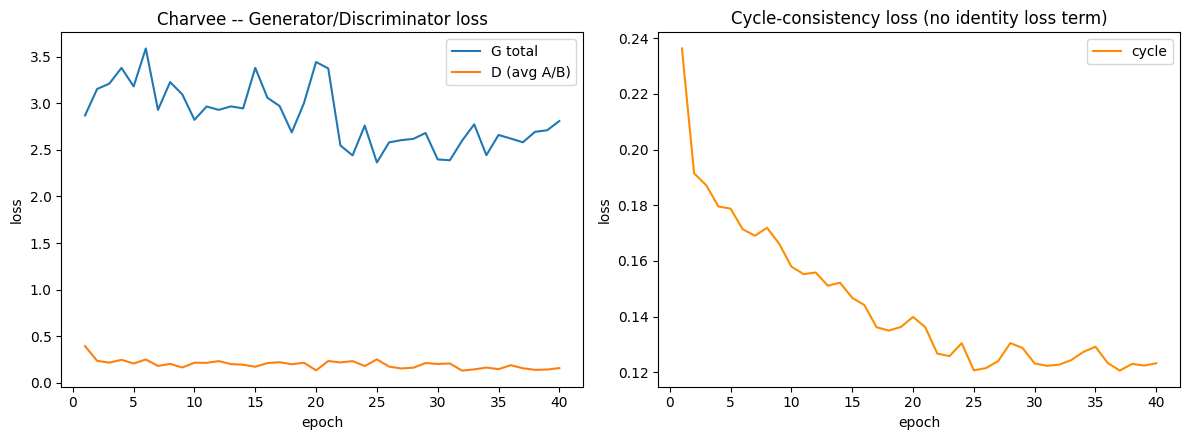

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history["epoch"], history["loss_G"], label="G total")
axes[0].plot(history["epoch"], history["loss_D"], label="D (avg A/B)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[0].set_title("Charvee -- Generator/Discriminator loss")
axes[1].plot(history["epoch"], history["loss_cycle"], label="cycle", color="darkorange")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("loss"); axes[1].legend()
axes[1].set_title("Cycle-consistency loss (no identity loss term)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curves.png"), dpi=130)
plt.show()

### 3.2 Evaluation: generate translations on the held-out test images

In [7]:
G_AB.eval(); G_BA.eval()
real_A_test = load_eval_batch(monet_test_sample, eval_transform, N_TEST).to(device)
real_B_test = load_eval_batch(photo_test_sample, eval_transform, N_TEST).to(device)

with torch.no_grad():
    t0 = time.time()
    fake_B_test = G_AB(real_A_test)
    fake_A_test = G_BA(real_B_test)
    gen_time = time.time() - t0
    rec_A_test = G_BA(fake_B_test)
    rec_B_test = G_AB(fake_A_test)

gen_images_per_sec = (real_A_test.size(0) + real_B_test.size(0)) / gen_time


def save_grid(tensor_batch, path, n=8):
    imgs = ((tensor_batch[:n].clamp(-1, 1) + 1) / 2 * 255).byte().cpu().permute(0, 2, 3, 1).numpy()
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i])
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=110)
    plt.close()


save_grid(fake_B_test, os.path.join(OUT_DIR, "pred_A2B", "sample_grid.png"))
save_grid(fake_A_test, os.path.join(OUT_DIR, "pred_B2A", "sample_grid.png"))


def save_individual(tensor_batch, out_folder, prefix):
    imgs = ((tensor_batch.clamp(-1, 1) + 1) / 2 * 255).byte().cpu().permute(0, 2, 3, 1).numpy()
    for i, img in enumerate(imgs):
        Image.fromarray(img).save(os.path.join(out_folder, f"{prefix}_{i:03d}.jpg"))


save_individual(fake_B_test, os.path.join(OUT_DIR, "pred_A2B"), "monet2photo")
save_individual(fake_A_test, os.path.join(OUT_DIR, "pred_B2A"), "photo2monet")

### Full metrics: FID/KID (both directions), cycle L1, LPIPS, content-preservation cosine sim

In [8]:
import sys
COMMON_DIR = os.path.abspath(os.path.join(MEMBER_DIR, "..", "..", "common"))
sys.path.insert(0, COMMON_DIR)
from eval_gan import compute_fid_kid, cycle_reconstruction_l1, ContentFeatureExtractor, lpips_distance  # noqa: E402

fid_kid_A2B = compute_fid_kid(real_B_test, fake_B_test, device=device)
fid_kid_B2A = compute_fid_kid(real_A_test, fake_A_test, device=device)

cycle_l1_A = cycle_reconstruction_l1(real_A_test, rec_A_test)
cycle_l1_B = cycle_reconstruction_l1(real_B_test, rec_B_test)

content_extractor = ContentFeatureExtractor(device=device)
content_sim_A2B = content_extractor.cosine_similarity(real_A_test, fake_B_test)
content_sim_B2A = content_extractor.cosine_similarity(real_B_test, fake_A_test)

lpips_A2B = lpips_distance(real_A_test, fake_B_test, device=device)
lpips_B2A = lpips_distance(real_B_test, fake_A_test, device=device)

final_metrics = {
    "member": "Charvee",
    "architecture": "U-Net generator (4 down/up, skip connections, BatchNorm) + PatchGAN, vanilla GAN loss, no identity loss",
    "img_size": IMG_SIZE, "epochs": EPOCHS, "batch_size": BATCH_SIZE,
    "lambda_cycle": LAMBDA_CYCLE, "lambda_identity": 0.0,
    "n_train_monet": len(monet_sample), "n_train_photo": len(photo_sample),
    "fid_monet2photo": fid_kid_A2B["fid"], "kid_monet2photo_mean": fid_kid_A2B["kid_mean"], "kid_monet2photo_std": fid_kid_A2B["kid_std"],
    "fid_photo2monet": fid_kid_B2A["fid"], "kid_photo2monet_mean": fid_kid_B2A["kid_mean"], "kid_photo2monet_std": fid_kid_B2A["kid_std"],
    "cycle_l1_monet": cycle_l1_A, "cycle_l1_photo": cycle_l1_B,
    "lpips_monet2photo": lpips_A2B, "lpips_photo2monet": lpips_B2A,
    "content_cosine_sim_monet2photo": content_sim_A2B, "content_cosine_sim_photo2monet": content_sim_B2A,
    "final_loss_G": history["loss_G"][-1], "final_loss_D": history["loss_D"][-1],
    "final_loss_cycle": history["loss_cycle"][-1],
    "grad_norm_G_mean": float(np.mean(history["grad_norm_G"])), "grad_norm_G_max": float(np.max(history["grad_norm_G"])),
    "nan_count": nan_count,
    "param_count_total": n_params_total,
    "training_time_sec": train_time_sec, "train_images_per_sec": images_per_sec,
    "gen_images_per_sec": gen_images_per_sec,
    "peak_memory_MB": peak_mem_mb,
}

import csv
with open(os.path.join(MEMBER_DIR, "metrics_report.csv"), "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(final_metrics.keys()))
    w.writeheader()
    w.writerow(final_metrics)

with open(os.path.join(HERE, "full_metrics_report.csv"), "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(final_metrics.keys()))
    w.writeheader()
    w.writerow(final_metrics)

print("\n=== FINAL METRICS (Charvee, Task 3) ===")
for k, v in final_metrics.items():
    print(f"{k}: {v}")

C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\lpips\weights\v0.1\alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


Loading model from: C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\lpips\weights\v0.1\alex.pth

=== FINAL METRICS (Charvee, Task 3) ===
member: Charvee
architecture: U-Net generator (4 down/up, skip connections, BatchNorm) + PatchGAN, vanilla GAN loss, no identity loss
img_size: 128
epochs: 40
batch_size: 4
lambda_cycle: 8.0
lambda_identity: 0.0
n_train_monet: 400
n_train_photo: 400
fid_monet2photo: 2.128333806991577
kid_monet2photo_mean: 3.419201612472534
kid_monet2photo_std: 1.9562698071240447e-05
fid_photo2monet: 1.1034986972808838
kid_photo2monet_mean: 0.2580264210700989
kid_photo2monet_std: 6.811811999796191e-06
cycle_l1_monet: 0.1132308766245842
cycle_l1_photo: 0.10383954644203186
lpips_monet2photo: 0.47374773025512695
lpips_photo2monet: 0.48854684829711914
content_cosine_sim_monet2photo: 0.7386698126792908
content_cosine_sim_photo2monet: 0.6009327173233032
final_loss_G: 2.809352271556854